In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier

In [3]:
train_signals = pd.read_csv("/Users/dianafatykhova/Downloads/fintech_data/train_signals.csv")
test_signals = pd.read_csv("/Users/dianafatykhova/Downloads/fintech_data/test_signals.csv")

train_transactions = pd.read_csv("/Users/dianafatykhova/Downloads/fintech_data/train_transactions.csv")
test_transactions = pd.read_csv("/Users/dianafatykhova/Downloads/fintech_data/test_transactions.csv")

sample_submission = pd.read_csv("/Users/dianafatykhova/Downloads/fintech_data/sample_submission.csv")

In [4]:
print("Train signals:", train_signals.shape)
print("Test signals:", test_signals.shape)

print("Train transactions:", train_transactions.shape)
print("Test transactions:", test_transactions.shape)

Train signals: (14000, 3)
Test signals: (6000, 2)
Train transactions: (6987663, 5)
Test transactions: (3027575, 5)


In [5]:
train_signals.head()
train_transactions.head()
train_signals.info()
train_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   signal_id      14000 non-null  str  
 1   signal_sanasi  14000 non-null  str  
 2   eskalatsiya    14000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 588.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 6987663 entries, 0 to 6987662
Data columns (total 5 columns):
 #   Column             Dtype  
---  ------             -----  
 0   signal_id          str    
 1   tranzaksiya_vaqti  str    
 2   kirim_chiqim       str    
 3   tranzaksiya_turi   str    
 4   miqdor_indeksi     float64
dtypes: float64(1), str(4)
memory usage: 544.7 MB


In [6]:
train_signals["eskalatsiya"].value_counts()
train_signals["eskalatsiya"].value_counts(normalize=True)


eskalatsiya
0    0.828214
1    0.171786
Name: proportion, dtype: float64

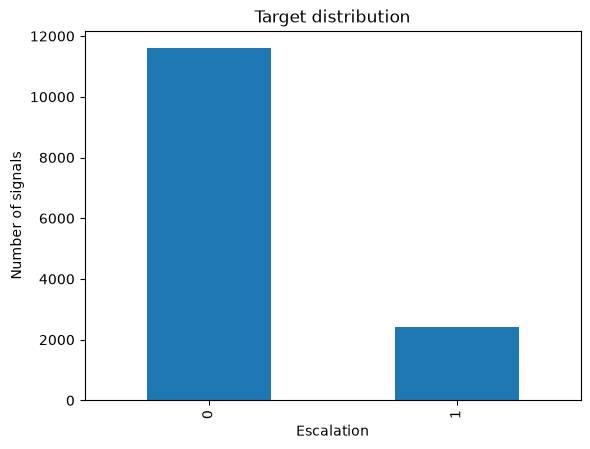

In [7]:
train_signals["eskalatsiya"].value_counts().plot(kind="bar")
plt.title("Target distribution")
plt.xlabel("Escalation")
plt.ylabel("Number of signals")
plt.show()


In [8]:
train_signals["signal_sanasi"] = pd.to_datetime(
    train_signals["signal_sanasi"]
)

test_signals["signal_sanasi"] = pd.to_datetime(
    test_signals["signal_sanasi"]
)

train_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    train_transactions["tranzaksiya_vaqti"]
)

test_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    test_transactions["tranzaksiya_vaqti"]
)

In [9]:
train_transactions = train_transactions.merge(
    train_signals[["signal_id", "signal_sanasi"]],
    on="signal_id",
    how="left"
)

test_transactions = test_transactions.merge(
    test_signals[["signal_id", "signal_sanasi"]],
    on="signal_id",
    how="left"
)

In [10]:
train_transactions.head()

,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi,signal_sanasi
0,SG_016527,2024-07-06 08:47:18,chiqim,bank_otkazmasi,0.236245,2025-01-02
1,SG_016527,2024-07-07 02:13:02,chiqim,bank_otkazmasi,1.130377,2025-01-02
2,SG_016527,2024-07-08 11:15:12,kirim,karta,0.466360,2025-01-02
3,SG_016527,2024-07-08 15:58:21,kirim,karta,-0.591761,2025-01-02
4,SG_016527,2024-07-09 02:33:17,kirim,bank_otkazmasi,-1.108945,2025-01-02


In [11]:
train_transactions["days_before_signal"] = (
    train_transactions["signal_sanasi"]
    - train_transactions["tranzaksiya_vaqti"]
).dt.total_seconds() / 86400


In [12]:

test_transactions["days_before_signal"] = (
    test_transactions["signal_sanasi"]
    - test_transactions["tranzaksiya_vaqti"]
).dt.total_seconds() / 86400

In [13]:
print(test_transactions.columns.tolist())

['signal_id', 'tranzaksiya_vaqti', 'kirim_chiqim', 'tranzaksiya_turi', 'miqdor_indeksi', 'signal_sanasi', 'days_before_signal']


In [14]:
test_transactions = test_transactions[
    test_transactions["days_before_signal"] >= 0
].copy()

In [15]:
train_transactions = train_transactions[
    train_transactions["days_before_signal"] >= 0
].copy()

In [56]:
def create_basic_features(transactions):

    features = pd.DataFrame(
        index=transactions["signal_id"].unique()
    )

    features.index.name = "signal_id"

    features["tx_count"] = (
        transactions.groupby("signal_id").size()
    )

    amount_stats = (
        transactions
        .groupby("signal_id")["miqdor_indeksi"]
        .agg(["mean", "std", "min", "max", "median", "sum"])
    )

    amount_stats.columns = [
        "amount_mean",
        "amount_std",
        "amount_min",
        "amount_max",
        "amount_median",
        "amount_sum"
    ]

    features = features.join(amount_stats)

    direction = pd.crosstab(
        transactions["signal_id"],
        transactions["kirim_chiqim"]
    )

    direction = direction.rename(
        columns={
            "kirim": "incoming_count",
            "chiqim": "outgoing_count"
        }
    )

    features = features.join(direction)

    tx_type = pd.crosstab(
        transactions["signal_id"],
        transactions["tranzaksiya_turi"]
    )

    tx_type = tx_type.add_prefix("type_count_")

    features = features.join(tx_type)

    features["days_since_last_transaction"] = (
        transactions
        .groupby("signal_id")["days_before_signal"]
        .min()
    )

    return features.reset_index()

In [57]:
train_features = create_basic_features(train_transactions)

print(train_features.columns.tolist())

['signal_id', 'tx_count', 'amount_mean', 'amount_std', 'amount_min', 'amount_max', 'amount_median', 'amount_sum', 'outgoing_count', 'incoming_count', 'type_count_bank_otkazmasi', 'type_count_karta', 'type_count_naqd', 'type_count_xalqaro', 'days_since_last_transaction']


In [58]:
train_model_data = train_signals.merge(
    train_features,
    on="signal_id",
    how="left"
)

In [59]:
print(train_features.head())
print(train_features.columns.tolist())
print(train_features["signal_id"].head())

   signal_id  tx_count  amount_mean  amount_std  amount_min  amount_max  \
0  SG_016527       152    -0.129880    0.783860   -1.829257    2.720041   
1  SG_004278       221     0.323456    1.209663   -2.214980    4.351575   
2  SG_014060       244     0.846005    0.912670   -1.464149    3.598912   
3  SG_011195       404    -0.083082    0.817772   -2.101576    3.478251   
4  SG_008270       259    -0.015937    0.880633   -2.018150    2.480156   

   amount_median  amount_sum  outgoing_count  incoming_count  \
0      -0.232146  -19.741741              57              95   
1       0.139138   71.483696              51             170   
2       0.710116  206.425114              80             164   
3      -0.139743  -33.565082              15             389   
4      -0.081996   -4.127628              37             222   

   type_count_bank_otkazmasi  type_count_karta  type_count_naqd  \
0                         62                83                7   
1                        105  

In [66]:
test_features = create_basic_features(test_transactions)

print(test_features.columns.tolist())

['signal_id', 'tx_count', 'amount_mean', 'amount_std', 'amount_min', 'amount_max', 'amount_median', 'amount_sum', 'outgoing_count', 'incoming_count', 'type_count_bank_otkazmasi', 'type_count_karta', 'type_count_naqd', 'type_count_xalqaro', 'days_since_last_transaction']


In [65]:
test_model_data = test_signals.merge(
    test_features,
    on="signal_id",
    how="left"
)

In [67]:
train_model_data = train_model_data.fillna(0)
test_model_data = test_model_data.fillna(0)

In [68]:
y = train_model_data["eskalatsiya"]

In [69]:
feature_columns = [
    col for col in train_model_data.columns
    if col not in ["signal_id", "signal_sanasi", "eskalatsiya"]
]

In [70]:
X = train_model_data[feature_columns]
y = train_model_data["eskalatsiya"]

In [71]:
X.head()

,tx_count,amount_mean,amount_std,amount_min,amount_max,amount_median,amount_sum,outgoing_count,incoming_count,type_count_bank_otkazmasi,type_count_karta,type_count_naqd,type_count_xalqaro,days_since_last_transaction
0,203,0.437551,1.283484,-2.889532,3.816146,0.503799,88.822846,68,135,111,77,15,0,0.000000
1,271,0.327211,0.714104,-1.705973,3.806999,0.298081,88.674149,88,183,174,69,26,2,0.000046
2,760,0.025983,0.997670,-2.744819,4.498756,-0.065040,19.747271,130,630,272,473,15,0,0.000000
3,432,0.278599,0.852941,-1.783126,3.418567,0.263466,120.354553,129,303,173,236,20,3,0.000035
4,392,0.643715,0.973805,-2.046955,3.578128,0.629593,252.336357,130,262,202,156,33,1,0.000000


In [72]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: eskalatsiya, dtype: int64

In [73]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
print(X_train.shape)
print(X_val.shape)

(11200, 14)
(2800, 14)


In [75]:
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    eval_metric="AUC",
    verbose=50,
    random_seed=42
)

In [76]:
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

0:	test: 0.5550250	best: 0.5550250 (0)	total: 65.4ms	remaining: 19.6s
50:	test: 0.6081623	best: 0.6108662 (38)	total: 158ms	remaining: 772ms
100:	test: 0.6098388	best: 0.6115207 (78)	total: 252ms	remaining: 497ms
150:	test: 0.6116713	best: 0.6123410 (146)	total: 358ms	remaining: 353ms
200:	test: 0.6100907	best: 0.6123410 (146)	total: 461ms	remaining: 227ms
250:	test: 0.6084116	best: 0.6123410 (146)	total: 563ms	remaining: 110ms
299:	test: 0.6040205	best: 0.6123410 (146)	total: 656ms	remaining: 0us

bestTest = 0.6123409707
bestIteration = 146

Shrink model to first 147 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, random_seed=42, verbose=50)

In [77]:
val_predictions = model.predict_proba(X_val)[:, 1]

In [78]:
val_predictions[:10]

array([0.11806719, 0.09856217, 0.16542807, 0.22106043, 0.11904922,
       0.18315456, 0.18095312, 0.06318995, 0.09093788, 0.17603556])

In [79]:
auc = roc_auc_score(
    y_val,
    val_predictions
)

print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.6123409706850846


In [80]:
importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
3,amount_min,20.928427
4,amount_max,9.637513
7,outgoing_count,9.127729
11,type_count_naqd,7.951392
9,type_count_bank_otkazmasi,7.880437
2,amount_std,7.401182
10,type_count_karta,5.098293
1,amount_mean,5.071023
8,incoming_count,4.828045
0,tx_count,4.772309


In [81]:
final_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    eval_metric="AUC",
    verbose=50,
    random_seed=42
)

In [82]:
final_model.fit(X, y)

0:	total: 6.47ms	remaining: 1.93s
50:	total: 109ms	remaining: 530ms
100:	total: 205ms	remaining: 403ms
150:	total: 302ms	remaining: 298ms
200:	total: 396ms	remaining: 195ms
250:	total: 494ms	remaining: 96.4ms
299:	total: 596ms	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, random_seed=42, verbose=50)

In [83]:
X_test = test_model_data[feature_columns]

In [84]:
print(X.shape)
print(X_test.shape)

(14000, 14)
(6000, 14)


In [85]:
test_predictions = final_model.predict_proba(X_test)[:, 1]

In [86]:
test_predictions[:20]

array([0.16022999, 0.23394972, 0.13825099, 0.13050362, 0.09057677,
       0.17424914, 0.17956182, 0.21571119, 0.16599529, 0.23468041,
       0.131248  , 0.1335619 , 0.16732125, 0.15954861, 0.18757367,
       0.26361565, 0.05532966, 0.26837011, 0.19319556, 0.12455095])

In [87]:
test_predictions.min(), test_predictions.max()

(np.float64(0.024844347243868255), np.float64(0.641386395760409))

In [88]:
sample_submission.head()

,signal_id,ehtimollik
0,SG_000001,0.5
1,SG_000007,0.5
2,SG_000009,0.5
3,SG_000010,0.5
4,SG_000011,0.5


In [89]:
sample_submission.columns

Index(['signal_id', 'ehtimollik'], dtype='str')

In [90]:
submission = sample_submission.copy()

submission["eskalatsiya"] = test_predictions

In [91]:
submission.head()

,signal_id,ehtimollik,eskalatsiya
0,SG_000001,0.5,0.160230
1,SG_000007,0.5,0.233950
2,SG_000009,0.5,0.138251
3,SG_000010,0.5,0.130504
4,SG_000011,0.5,0.090577


In [92]:
print(sample_submission.columns.tolist())

['signal_id', 'ehtimollik']


In [93]:
submission = sample_submission.copy()

submission["ehtimollik"] = test_predictions

In [95]:
submission.head()

,signal_id,ehtimollik
0,SG_000001,0.160230
1,SG_000007,0.233950
2,SG_000009,0.138251
3,SG_000010,0.130504
4,SG_000011,0.090577


In [96]:
submission.to_csv(
    "/Users/dianafatykhova/Downloads/baseline_day1.csv",
    index=False
)